In [1]:
# 匯入 yfinance 套件
import yfinance as yf

# 台積電在 Yahoo Finance 的股票代碼為 2330.TW
tsmc = yf.Ticker("2330.TW")

# 取得近 5 個交易日的歷史股價資料
hist = tsmc.history(period="5d")

# 印出歷史股價
print("=== 近 5 日歷史股價 ===")
print(hist)

# 取得最新一筆收盤價
print(f"\n最新收盤價: {hist['Close'].iloc[-1]}")

=== 近 5 日歷史股價 ===
                             Open    High     Low   Close    Volume  \
Date                                                                  
2026-07-15 00:00:00+08:00  2425.0  2460.0  2415.0  2440.0  28532735   
2026-07-16 00:00:00+08:00  2430.0  2470.0  2420.0  2470.0  27848158   
2026-07-17 00:00:00+08:00  2375.0  2395.0  2290.0  2290.0  75253147   
2026-07-20 00:00:00+08:00  2300.0  2345.0  2300.0  2320.0  45272691   
2026-07-21 00:00:00+08:00  2350.0  2410.0  2345.0  2410.0  31271386   

                           Dividends  Stock Splits  
Date                                                
2026-07-15 00:00:00+08:00        0.0           0.0  
2026-07-16 00:00:00+08:00        0.0           0.0  
2026-07-17 00:00:00+08:00        0.0           0.0  
2026-07-20 00:00:00+08:00        0.0           0.0  
2026-07-21 00:00:00+08:00        0.0           0.0  

最新收盤價: 2410.0


In [2]:
# 取得台積電公司基本資訊
info = tsmc.info
print("=== 台積電公司資訊 ===")
print(f"公司名稱: {info.get('longName', 'N/A')}")
print(f"產業類別: {info.get('industry', 'N/A')}")
print(f"市值: {info.get('marketCap', 'N/A')}")
print(f"本益比: {info.get('trailingPE', 'N/A')}")
print(f"股利殖利率: {info.get('dividendYield', 'N/A')}")

=== 台積電公司資訊 ===
公司名稱: Taiwan Semiconductor Manufacturing Company Limited
產業類別: Semiconductors
市值: 62497012842496
本益比: 32.771282
股利殖利率: 1.03


C:\Users\User\AppData\Local\Temp\ipykernel_3620\2924532258.py:12: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3620\2924532258.py:12: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3620\2924532258.py:12: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3620\2924532258.py:12: UserWarning: Glyph 30436 (\N{CJK UNIFIED IDEOGRAPH-76E4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3620\2924532258.py:12: UserWarning: Glyph 20729 (\N{CJK UNIFIED IDEOGRAPH-50F9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3620\2924532258.py:12: UserWarning: Glyph 21488 (\N{CJK UNIFIE

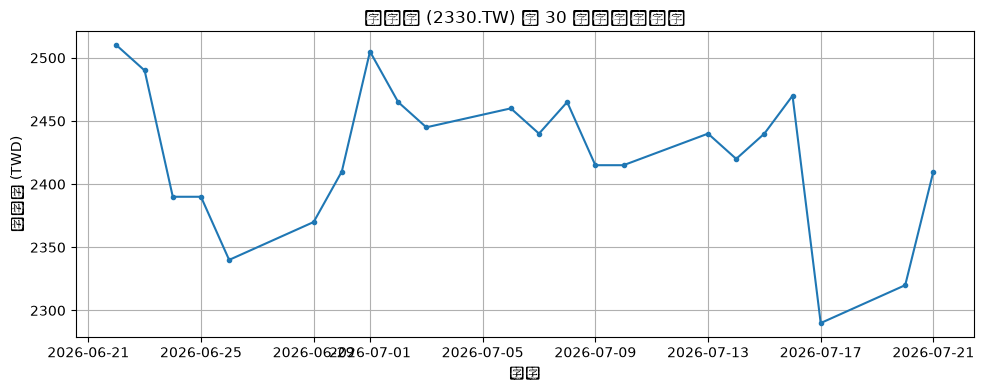

In [6]:
# 取得近 30 日歷史資料，並繪製收盤價走勢圖
import matplotlib.pyplot as plt

hist_30d = tsmc.history(period="1mo")

plt.figure(figsize=(10, 4))
plt.plot(hist_30d.index, hist_30d['Close'], marker='o', markersize=3)
plt.title('台積電 (2330.TW) 近 30 日收盤價走勢')
plt.xlabel('日期')
plt.ylabel('收盤價 (TWD)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
import yfinance as yf
import matplotlib.pyplot as plt
from pandas import DataFrame

# 定義 period 對應表
PERIOD_MAP = {
    "1d": "1d",
    "1w": "5d",
    "1y": "1y",
}

def get_tsmc_history(period: str = "1d") -> DataFrame:
    """
    取得台積電歷史股價資料
    
    參數:
        period: "1d" (最近1天), "1w" (最近1週), "1y" (最近1年)
    
    回傳:
        DataFrame: 包含 Open, High, Low, Close, Volume 等欄位
    """
    # 驗證 period 參數
    if period not in PERIOD_MAP:
        raise ValueError(f"不支援的 period: {period}，請使用 '1d', '1w', '1y'")
    
    # 建立 TSMC Ticker 物件
    tsmc = yf.Ticker("2330.TW")
    
    # 抓取歷史資料
    hist = tsmc.history(period=PERIOD_MAP[period])
    
    return hist

def plot_tsmc_history(period: str = "1d") -> None:
    """
    繪製台積電歷史收盤價走勢圖
    
    參數:
        period: "1d" (最近1天), "1w" (最近1週), "1y" (最近1年)
    """
    hist = get_tsmc_history(period)
    
    # 設定標題標籤
    label_map = {"1d": "1日", "1w": "1週", "1y": "1年"}
    label = label_map[period]
    
    plt.figure(figsize=(10, 4))
    plt.plot(hist.index, hist['Close'], marker='o', markersize=3)
    plt.title(f'TSMC (2330.TW) - {label} Closing Price')
    plt.xlabel('Date')
    plt.ylabel('Close (TWD)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [8]:
# 範例：取得最近 1 天資料
df_1d = get_tsmc_history("1d")
print("=== 最近 1 日 ===")
print(df_1d)

# 範例：取得最近 1 週資料
df_1w = get_tsmc_history("1w")
print("\n=== 最近 1 週 ===")
print(df_1w)

# 範例：取得最近 1 年資料
df_1y = get_tsmc_history("1y")
print("\n=== 最近 1 年 ===")
print(df_1y)

=== 最近 1 日 ===
                             Open    High     Low   Close    Volume  \
Date                                                                  
2026-07-21 00:00:00+08:00  2350.0  2410.0  2345.0  2410.0  31271386   

                           Dividends  Stock Splits  
Date                                                
2026-07-21 00:00:00+08:00        0.0           0.0  

=== 最近 1 週 ===
                             Open    High     Low   Close    Volume  \
Date                                                                  
2026-07-15 00:00:00+08:00  2425.0  2460.0  2415.0  2440.0  28532735   
2026-07-16 00:00:00+08:00  2430.0  2470.0  2420.0  2470.0  27848158   
2026-07-17 00:00:00+08:00  2375.0  2395.0  2290.0  2290.0  75253147   
2026-07-20 00:00:00+08:00  2300.0  2345.0  2300.0  2320.0  45272691   
2026-07-21 00:00:00+08:00  2350.0  2410.0  2345.0  2410.0  31271386   

                           Dividends  Stock Splits  
Date                                         

C:\Users\User\AppData\Local\Temp\ipykernel_3620\2607821271.py:53: UserWarning: Glyph 36913 (\N{CJK UNIFIED IDEOGRAPH-9031}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\Documents\GitHub\_20260703\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36913 (\N{CJK UNIFIED IDEOGRAPH-9031}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


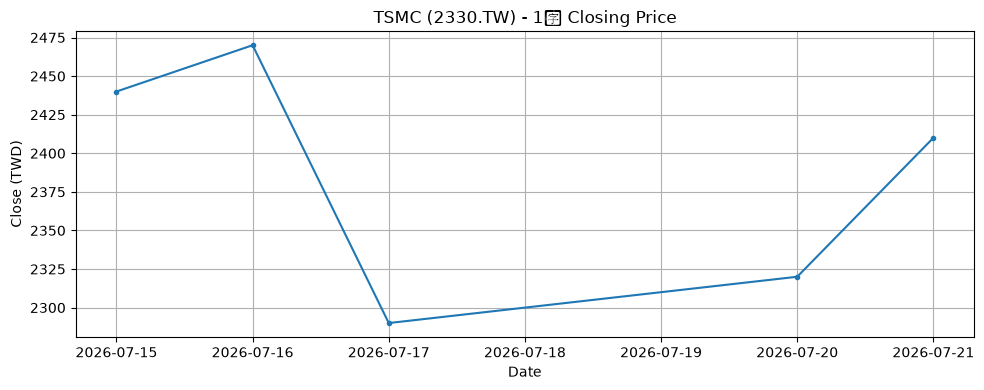

In [9]:
# 範例：繪製走勢圖
plot_tsmc_history("1w")